In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm
import seaborn as sns

#symtem 
import warnings

# Configuration
warnings.filterwarnings('ignore')

# Reading The Dataset
data = pd.read_excel(io= "C://Users//DELL//OneDrive//Bureau//MBA_Finance S1//6. Managerial Econoimics//Assignment 07_03_26//Group3.xls")

# 1. Save the current headers (which are actually your first row of data)
first_row_values = data.columns.tolist()

# 2. Assign the correct names to the columns
data.columns = ["sales", "price", "ad_spend", "price_sub", "gdp_pc", "internet_pen"]

In [3]:
# 3. Create a new row from the saved values and put it at the top (index 0)
new_row = pd.DataFrame([first_row_values], columns=data.columns)
df = pd.concat([new_row, data], ignore_index=True)

# 4. Check missing value
print(f"Cleaned Dataset:\n{df.isnull().sum()}".upper())

#Showing The Table
df.head(5)

CLEANED DATASET:
SALES           0
PRICE           0
AD_SPEND        0
PRICE_SUB       0
GDP_PC          0
INTERNET_PEN    0
DTYPE: INT64


,sales,price,ad_spend,price_sub,gdp_pc,internet_pen
0,29735250.0,22.746826,18.892509,24.133200,2484.122314,29.581167
1,105553808.0,23.896723,108.977882,22.863764,2791.537109,38.427612
2,60167416.0,34.445797,27.992220,31.380167,5616.959961,22.000778
3,59652864.0,22.495062,91.966057,21.298882,1816.280762,75.558472
4,17191268.0,32.960804,98.521690,32.429260,867.124878,29.778500


### **Section 1:**
Using charts plots to better understand data.

- 1. **Scatter plot**
- 2. **pairplot**
- 3. **correlation heatmaps**

***Dynamic tip:*** After seeing patterns, decide which variables are most likely to affect sales for your regression model.

### 1. **Scatter plot**

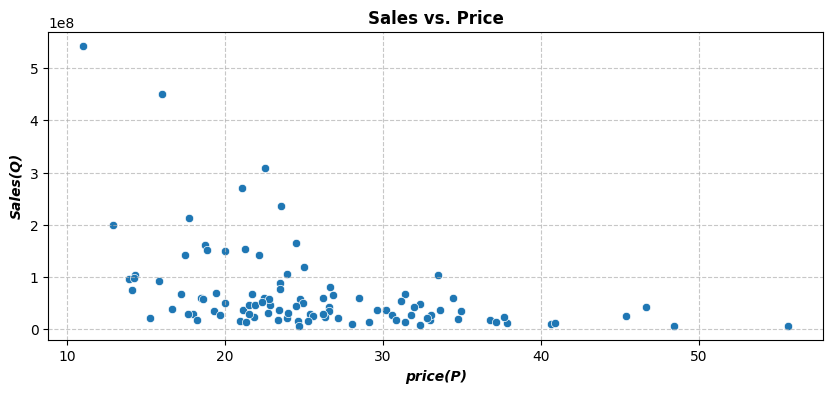

In [4]:
# Scatter plot: Sales vs Price
plt.figure(figsize=(10,4))

sns.scatterplot(data=df, x="price", y="sales")

plt.title("Sales vs. Price", fontweight='bold')
# Price Measure
plt.xlabel('price(P)', fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')

# Sales Measure
plt.ylabel("Sales(Q)", fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### 2. **Pairplot**

The pairplot is as many scatter plots combined into one big chart. And it shows scatter plots which is showing the relationship between variables, also shows histograms which is showing the distribution of each variable.

Deal with the meaning, on the diagonal you see how each variable is distributed. Sales histogram tells about small or extreme values.

Outside the diagonal we see scatter plots.
-   **sales vs price,**
If points go downward → higher price → lower sales then there is negative demand relationship.
- **sales vs ad_spend,**
if points go upward → more advertising → more sales then there is a positive relationship.

Also we have ***Random cloud* (no relationship)** means there is no direction, X does not affect Y and The independent variable (X) does not affect the dependent variable (Y), some cases are observables on the graph like price vs internet_pen and so on.

The pairplot can be used as a quick detection of relationships, patterns, correlations
or outliers.

In this case, we will focus on what can be affected.

***sales vs price*** → demand curve

***sales vs ad_spend*** → marketing effect

***sales vs gdp_pc*** → income effect

***sales vs price_sub*** → substitution effect 

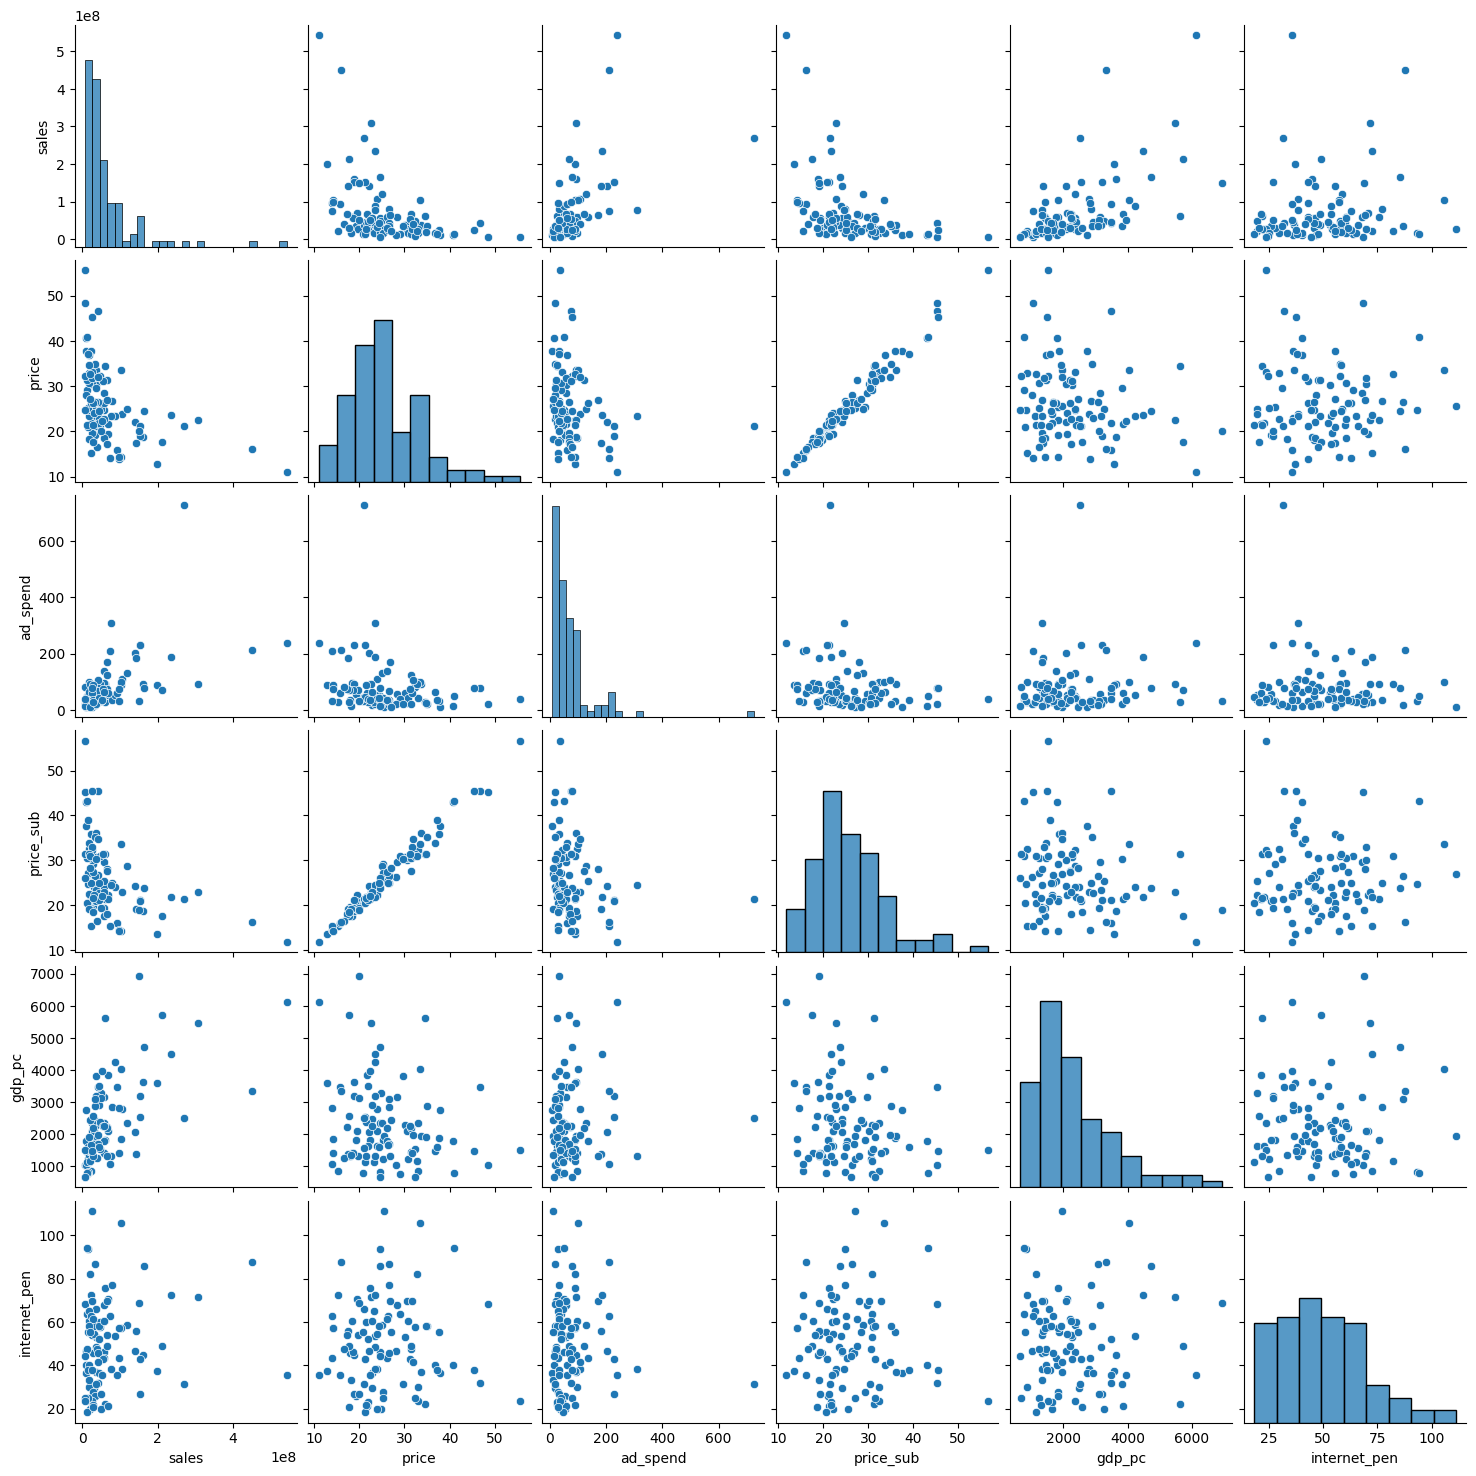

In [5]:
sns.pairplot(df)
plt.show()

### 3. **Correlation heatmaps**

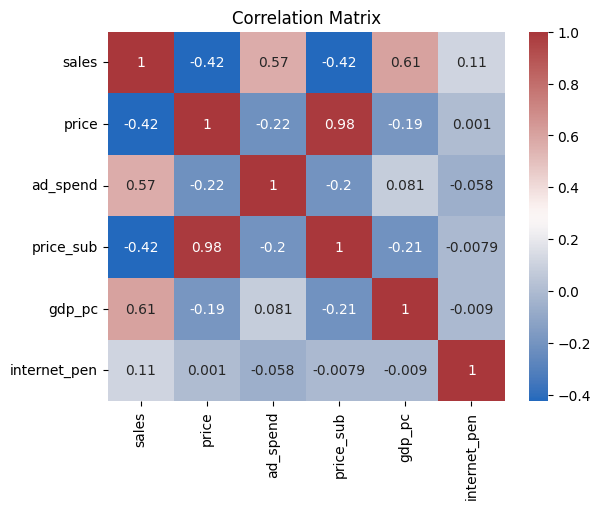

In [6]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='vlag')

plt.title("Correlation Matrix")
plt.show()

### **Section 2:**
1. **Descriptive statistics**
Summarize the basic features of your data (like the average or the range) so you can catch errors or weird patterns before you start calculating anything complex.
2. **Run two regressions** either linear or log linear model, This is Experimenting. You test two different functional forms to see how your independent variables (x) affect your dependent variable (y).
3. **Compare** You look at specific "fitness" markers for both models to see which one performs better. 

    **Key metrics include:**

    R-squared ($R^2$): Which model explains more of the variance in the data?
    P-values: Are the coefficients statistically significant in both models?
    Residual Analysis: Do the errors look random, or is there a pattern (heteroskedasticity)?

4. **choose**  based on statistical fit and theoretical sense pick the best-performing model to use for your final report or to make future predictions.


***Dynamic tip:*** The slope can be interpreted as elasticity if both variables are logged.



### 1. **Descriptive statistics**

#### **Forms:**

(a) **Mean** is the average value of a variable $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$
(b) **Standard Deviation** measures how spread out the data is from the mean $$s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$$
(c) **Minimum (Min)** the smallest value in a set of values

$\min(x)$

(d) **Maximum (Max)** the highest value in a set of values

$\max(x)$



In [7]:
stats = df.describe().T[['count', 'mean', 'std', 'min', 'max']]
stats

,count,mean,std,min,max
sales,100.0,6.788225e+07,8.477401e+07,6.100454e+06,5.431893e+08
price,100.0,2.572996e+01,8.092067e+00,1.104491e+01,5.561854e+01
ad_spend,100.0,7.660654e+01,8.778301e+01,1.031000e+01,7.269520e+02
price_sub,100.0,2.584208e+01,7.962862e+00,1.176252e+01,5.669821e+01
gdp_pc,100.0,2.306916e+03,1.263715e+03,6.556882e+02,6.941135e+03
internet_pen,100.0,5.036484e+01,2.004663e+01,1.817025e+01,1.112750e+02


### 2. **Linear Demand Model**

**Formulas:**

- **Linear Model**
$$Q = \beta_0 + \beta_1 P + \beta_2 \text{Income} + \epsilon$$
***in simple form*** $(Y = a + bX)$

So the demand model becomes:

$$\text{sales} = \beta_0 + \beta_1 \text{price} + \beta_2 \text{ad\_spend} + \beta_3 \text{price\_sub} + \beta_4 \text{gdp\_pc} + \beta_5 \text{internet\_pen} + \epsilon$$

**Meaning that Sales depend on price, advertising, substitute price, income and internet usage**

In [8]:
# Define dependent variable (Y)
# This is what we want to explain or predict.
# sales = demand

Y = data["sales"]

# Define independent variables (X)
# These are the factors that affect demand.
# So

X = data[["price","ad_spend","price_sub","gdp_pc","internet_pen"]]

# Add constant
# Because the regression needs β₀ (intercept).
# Without this step the equation would be wrong.

X = sm.add_constant(X)

# Estimate the regression
# OLS = Ordinary Least Squares
# It calculates the best coefficients that fit the data.

model_linear = sm.OLS(Y, X).fit()

print(model_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     45.71
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.33e-23
Time:                        08:54:10   Log-Likelihood:                -1886.3
No. Observations:                  99   AIC:                             3785.
Df Residuals:                      93   BIC:                             3800.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -2.452e+07   2.49e+07     -0.987   

In [9]:
# What R² Measures
# R² measures how well the independent variables explain the dependent variable.

Y = data["sales"]

X = data[["price","ad_spend","price_sub","gdp_pc","internet_pen"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(f"R-Squared: {model.rsquared.round(3)}".upper())

R-SQUARED: 0.711


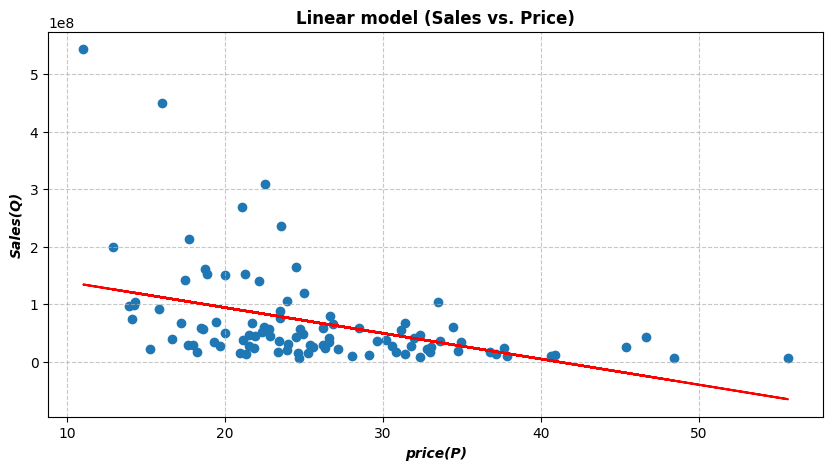

In [10]:
# Scatter plot
# Shows real observations.
# Each point = one row in your dataset.
plt.figure(figsize=(10,5))

plt.scatter(data["price"], data["sales"])

# Fit a straight line
# This estimates the linear equation

            # Sales = m * Price + b

# Where:

#       m = slope
#       b = intercept            

m, b = np.polyfit(data["price"], data["sales"], 1)

# Plot the line
plt.plot(data["price"], m*data["price"] + b, color='red')

plt.title("Linear model (Sales vs. Price)", fontweight='bold')

plt.xlabel('price(P)', fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')
plt.ylabel("Sales(Q)", fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

If the line slopes downward the ***price increases*** and ***sales decrease***

##### *This confirms the law of demand.*

### 3. **Log-Linear Model**

Instead of using the variables directly, we use their logarithms.

**Linear model** $$\text{sales} = \beta_0 + \beta_1 \text{price} + \beta_2 \text{ad\_spend} + \beta_3 \text{price\_sub} + \beta_4 \text{gdp\_pc} + \beta_5 \text{internet\_pen} + \epsilon$$

- ***You can compare both formulae to better understand the difference between them.***

**Log-linear model** $$\ln(\text{sales}) = \beta_0 + \beta_1 \ln(\text{price}) + \beta_2 \ln(\text{ad\_spend}) + \beta_3 \ln(\text{price\_sub}) + \beta_4 \ln(\text{gdp\_pc}) + \beta_5 \ln(\text{internet\_pen}) + \epsilon$$

This is called Log transformation.


In [11]:
# Transforming the variables
data["log_sales"] = np.log(data["sales"])
data["log_price"] = np.log(data["price"])
data["log_ad_spend"] = np.log(data["ad_spend"])
data["log_price_sub"] = np.log(data["price_sub"])
data["log_gdp_pc"] = np.log(data["gdp_pc"])
data["log_internet_pen"] = np.log(data["internet_pen"])

# Dependent variable
Y = data["log_sales"]

# Independent variables
X = data[["log_price","log_ad_spend","log_price_sub","log_gdp_pc","log_internet_pen"]]

# Adding constant
X = sm.add_constant(X)

# Regression
# This produces the log-linear regression table.
model_log = sm.OLS(Y, X).fit()

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     431.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.05e-62
Time:                        08:54:11   Log-Likelihood:                 22.806
No. Observations:                  99   AIC:                            -33.61
Df Residuals:                      93   BIC:                            -18.04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.3140      0.480  

In [12]:
# What R² Measures
# R² measures how well the independent variables explain the dependent variable.

Y = data["log_sales"]

X = data[["log_price","log_ad_spend","log_price_sub","log_gdp_pc","log_internet_pen"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(f"R-Squared: {model.rsquared.round(3)}".upper()) 

R-SQUARED: 0.959


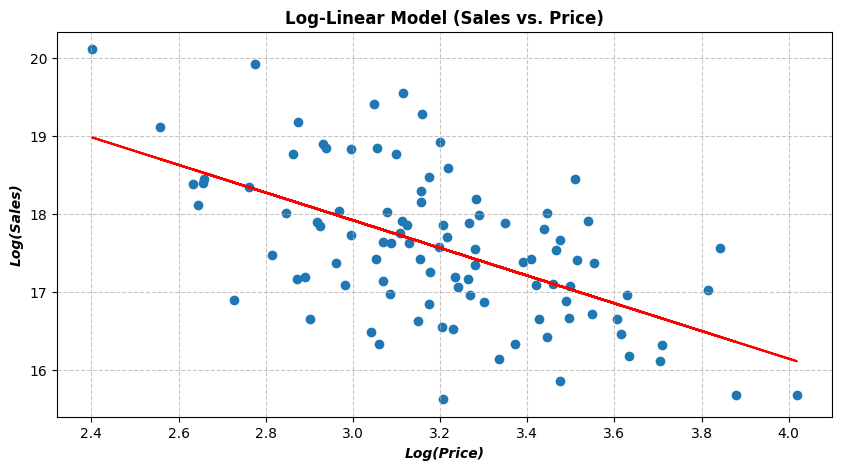

In [13]:
# create log variables
log_sales = np.log(data["sales"])
log_price = np.log(data["price"])

# graph size
plt.figure(figsize=(10,5))

# scatter plot
plt.scatter(log_price, log_sales)

# regression line
m, b = np.polyfit(log_price, log_sales, 1)
plt.plot(log_price, m*log_price + b, color='red')

plt.title("Log-Linear Model (Sales vs. Price)", fontweight='bold')

plt.xlabel('Log(Price)', fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')
plt.ylabel("Log(Sales)", fontsize= '10', fontweight= 'bold', fontstyle= 'italic', color='black')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

This indicates a negative relationship between price and sales.

***And confirm the law of demand.***

### 4. **Model Choice**

The objective is to choose the model that best explains the variation in the dependent variable (Sales).

A better fit simply means that predicted values are close to actual values (ŷᵢ ≈ yᵢ).

- The model is compared by using ***Fit Indicators***

(a) **Coefficient of Determination $R^2$ (R-squared)**

- ***Formulae***

$$R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}$$

\begin{aligned}
SST &= \sum (y_i - \bar{y})^2 && \text{Total variation} \\
SSR &= \sum (\hat{y}_i - \bar{y})^2 && \text{Explained variation} \\
SSE &= \sum (y_i - \hat{y}_i)^2 && \text{Error variation}
\end{aligned}

R² measures the proportion of variation in Sales explained by the model.

$$0 \le R^2 \le 1$$

- $R^2$ = 0.85 → 85% of variation explained

- Higher R² → better fit

(b) **Adjusted $R^2$**

AAdjusted R² is preferred when comparing models with different numbers of independent variables.

- ***Formulae***
$$\bar{R}^2 = 1 - \frac{\frac{SSE}{n - k - 1}}{\frac{SST}{n - 1}}$$

- 𝑛 = number of observations
- 𝑘 = number of independent variables

Can increase or decrease / Higher Adjusted R² → better model

(c) **(c) Error Measures**

 1. **Sum of Squared Errors (SSE)**

    Measures the total prediction error.

    ***Formula***
$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- Lower SSE → better fit
- If SSE = 0 → perfect fit

 2. **Mean Squared Error (MSE)**

    Average squared error per observation.

    ***Formula***
$$MSE = \frac{SSE}{n - k - 1}$$


- Lower MSE → better model

 3. **Root Mean Squared Error (RMSE)**

    Measures the average prediction error in the same unit as Sales.

    ***Formula***

$$RMSE = \sqrt{\frac{SSE}{n - k - 1}}$$

$${or}$$

$$RMSE = \sqrt{MSE}$$

- Lower RMSE → better fit
- Easy to interpret because it uses original units

4. **Log-Likelihood (Advanced)**

    Measures how likely the data is given the model.

    ***Formula (conceptual)***
$$LL = \sum_{i=1}^{n} \ln(f(y_i | \theta))$$

- Higher Log-Likelihood → better fit

4. **Information Criteria**

    Used when comparing different models

**(A) Akaike Information Criterion (AIC)**

***Formula***

$$AIC = -2LL + 2k$$

**(B) Bayesian Information Criterion (BIC)**

***Formula***

$$BIC = -2LL + k \ln(n)$$

They balance goodness of fit and model complexity by penalizing the inclusion of additional variables.

- Lower AIC → better model
- Lower BIC → better model

#### **Decision Rule**

When comparing Linear vs Log-linear model:

**Step 1**

Compare:

- Adjusted R²
- RMSE
- AIC / BIC

**Step 2**

Choose the model with:

- Higher Adjusted R²
- Lower RMSE
- Lower AIC / BIC

***In practice, the log-linear model is often preferred in demand analysis because it allows direct interpretation of coefficients as elasticities.***

### 5. **INTERPRETATION OF PREFERRED MODEL**

After estimating both models, you choose the best one based on Fit Indicators.

Deal with interpreting indicators economically and statistically.

(a) **Coefficient Interpretation**

It explains what each coefficient tells about demand.

#### **Linear Model**

*Interpretation rule:*

- **If X increases by 1 unit, Sales change by β**

Example:

 𝛽1 = − 400000

 Meaning that If price increases by 1 unit, sales decrease by 400,000 units, holding other factors constant.

#### **Log-Linear Model**

*Interpretation rule:*

- **If X increases by 1%, Sales change by β%**

Example:

 𝛽1 = − 0.8


Meaning that A 1% increase in price leads to a 0.8% decrease in sales.

This is price elasticity.

**Theoretical Signs**

It checks if the signs (+ or −) match economic theory.

Expected signs in demand

- **Variable              ->      Expected Sign   ->  Reason**
- *Price	                ->      Negative (−)    ->  law of demand*
- *Advertising	        ->      Positive (+)    ->  increases demand*
- *Income (GDP)          ->      Positive (+)    ->  higher income → more demand*
- *Substitute price      ->      Positive (+)    ->  substitute ↑ → your demand ↑*

#### **Statistical Significance (5% level)**

It checks which variables really matter.

**Rule using p-value:**
- **p-value    ->   Decision**
- p < 0.05    ->   significant
- p > 0.05    ->   not significant

#### **Overall Significance (F-test)**

It Overall Significance (F-test)

- **Hypotheses**

$$H_0: \beta_1 = \beta_2 = \beta_3 = 0$$

no variable affects sales

$$H_1: \text{At least one } \beta_j \neq 0$$

$$or$$

$$H_1: \exists \, j \in \{1, 2, 3\} \text{ s.t. } \beta_j \neq 0$$


at least one variable matters

#### **Decision Rule**

Look at F-test p-value:

**p-value            ->         Conclusion**
- ***$<$ 0.05        ->         reject H₀***
- ***$>$ 0.05        ->         fail to reject H₀***


Example

F-statistic p-value = 0.000

Conclusion:

We reject the null hypothesis. The model is statistically significant overall, meaning that at least one independent variable explains variations in sales.
 
#### **F-test**

It checks the model as a whole

Not individual variables

It Answers:

“Is this model useful or just random?”

### 6. **MODEL DIAGNOSTICS (TESTING ASSUMPTIONS)**

After choosing your preferred model, you must check if the OLS assumptions are valid.
If assumptions fail → your results may be misleading.

#### (a) **Multicollinearity**

- **What it is?**

Multicollinearity occurs when independent variables are highly correlated with each other.

Example:

GDP and income → move together

Price and substitute price → similar behavior

- **How to detect it?**

***Correlation Matrix***

High correlation: $|corr| > 0.8 → problem$

***Variance Inflation Factor (VIF)***

***Formula***
$$VIF_j = \frac{1}{1 - R_j^2}$$


$R_j^2 = R^2 \text{ from regressing variable } X_j \text{ on other } X\text{'s}$

$or$

$R_j^2 = \text{Coefficient of Determination for } X_j = f(X_1, \dots, X_{j-1}, X_{j+1}, \dots, X_k)$

**Rule of Thumb:**
- ***VIF -> Interpretation***

- $< 5$	    -> OK
- $5 – 10$    ->	moderate
- $> 10$      ->	serious multicollinearity

- ##### **VIP**
The Variance Inflation Factor (VIF) was used to detect multicollinearity.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

           Variable         VIF
0             const  581.065852
1         log_price   33.197110
2      log_ad_spend    1.096283
3     log_price_sub   33.200248
4        log_gdp_pc    1.055658
5  log_internet_pen    1.007258


#### (b) **Heteroskedasticity**

- **What it is?**

Heteroskedasticity occurs when the variance of the errors is not constant.

In simple terms:
*Errors are small for some observations and large for others*

- **Assumption**

$$\text{Var}(\varepsilon_i) = \sigma^2, \quad \forall \, i = 1, \dots, n$$

Must be constant (homoskedasticity).

- **Test: Breusch–Pagan Test**

 ***Hypotheses:***

$$
\begin{aligned}
H_0 &: \text{Homoskedasticity (constant variance)} \\
H_1 &: \text{Heteroskedasticity}
\end{aligned}
$$

***Mathematical Version of Hypotheses***

$$
\begin{aligned}
H_0 &: \sigma_1^2 = \sigma_2^2 = \dots = \sigma_n^2 = \sigma^2 \\
H_1 &: \text{Not all } \sigma_i^2 \text{ are equal}
\end{aligned}
$$

- *Decision Rule*

$$p-value → Conclusion$$
$$< 0.05  → reject H₀ → heteroskedasticity$$
$$> 0.05  → fail to reject H₀$$

- ##### **Breusch-Pagan**
The Breusch-Pagan test was conducted to assess heteroskedasticity. The results indicate that heteroskedasticity is present (p-value < 0.05). As a result, robust standard errors were applied.

In [15]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]
dict(zip(labels, bp_test))

{'LM Statistic': np.float64(4.434173564500627),
 'LM-Test p-value': np.float64(0.4887388014372914),
 'F-Statistic': np.float64(0.8721504523197486),
 'F-Test p-value': np.float64(0.5029936618256069)}

- ##### **Correction**

In [16]:
robust_model = model.get_robustcov_results()
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     583.0
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.48e-68
Time:                        08:54:11   Log-Likelihood:                 22.806
No. Observations:                  99   AIC:                            -33.61
Df Residuals:                      93   BIC:                            -18.04
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.3140      0.488  

#### (c) **Normality of Residuals**

- **What it is?**

Residuals should follow a normal distribution
$$\varepsilon_i \sim N(0, \sigma^2)$$


Normality is important for *"valid t-tests"* and *"valid F-tests"*

- **How to test?**

 **Jarque–Bera Test**

***Hypotheses***
$$
\begin{aligned}
H_0 &: \text{Residuals are normally distributed} \\
H_1 &: \text{Not normal}
\end{aligned}
$$

***Mathematical Version of Hypotheses***
$$H_1: \varepsilon_i \not\sim N(0, \sigma^2)$$


- *Decision Rule*
$$p-value   →    Conclusion$$
$$< 0.05    →   not normal$$
$$> 0.05    →   normal$$


**Other methods**

- *Histogram*
- *Q-Q plot*

- ##### **Jarque-Bera**

The Jarque-Bera test was used to examine the normality of residuals. The results show that the residuals are normally distributed, as the p-value is greater than 0.05.

In [17]:
from scipy.stats import jarque_bera

jb_test = jarque_bera(model.resid)

print("JB Statistic:", jb_test.statistic)
print("p-value:", jb_test.pvalue)

JB Statistic: 0.9142454171015713
p-value: 0.6331026481876711


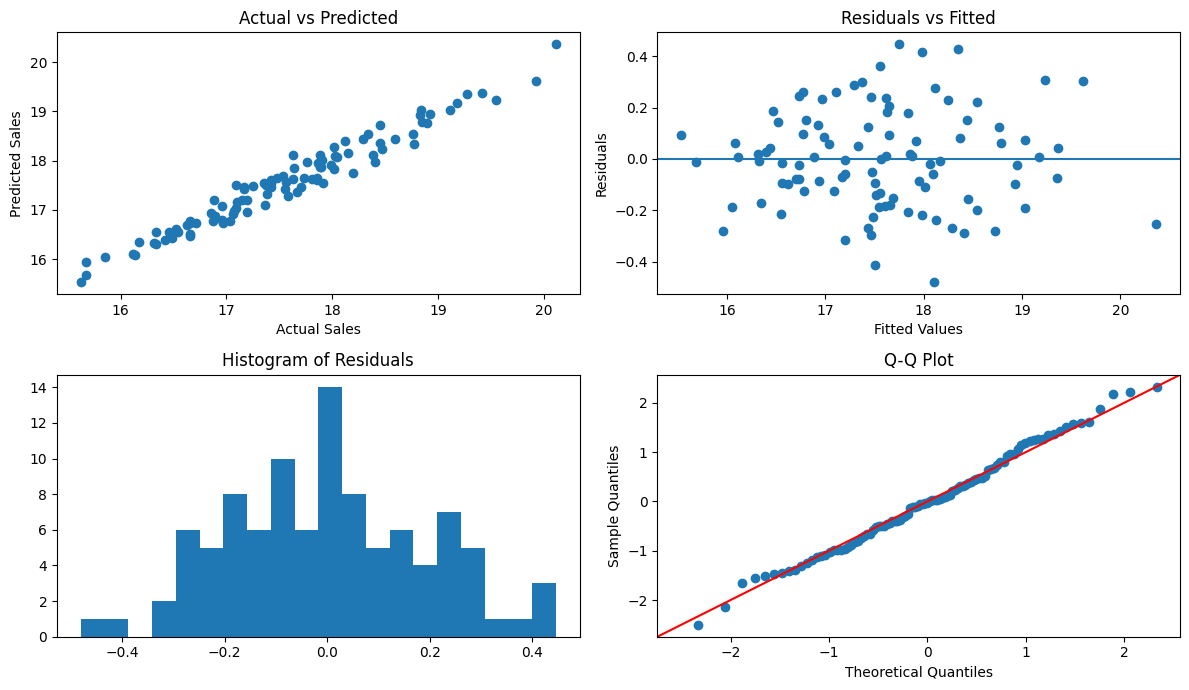

In [18]:
y_pred = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(12,7))

# (1) Actual vs Predicted
plt.subplot(2,2,1)
plt.scatter(Y, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

# (2) Residuals vs Fitted
plt.subplot(2,2,2)
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

# (3) Histogram
plt.subplot(2,2,3)
plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")

# (4) Q-Q Plot (FIXED)
plt.subplot(2,2,4)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title("Q-Q Plot")

plt.tight_layout()
plt.show()

### 1. **Actual vs Predicted**

- **GOOD CASE**
The scatter plot of actual versus predicted sales shows that most points lie relatively close to the 45-degree line, indicating that the model provides a good fit to the data. However, some dispersion is observed, suggesting that the model does not perfectly explain all variations in sales.

- **BAD CASE**
The points are widely dispersed from the 45-degree line, indicating that the model has limited explanatory power and does not fit the data well.

### 2. **Residuals vs Fitted (Heteroskedasticity)**

- **If RANDOM (good case)**
The residuals appear randomly scattered around zero with no clear pattern, suggesting that the assumption of homoskedasticity is satisfied.

- **If FUNNEL SHAPE (problem)**
The residual plot shows a funnel-shaped pattern, indicating the presence of heteroskedasticity. This suggests that the variance of the error terms is not constant.

### 3. **Histogram (Normality)**
- **If BELL SHAPE**
The histogram of residuals appears approximately bell-shaped, suggesting that the residuals are normally distributed.

- **If SKEWED**
The histogram shows skewness, indicating that the residuals deviate from normality.

### 4. **Q-Q Plot (Strong Normality Test)**

- **If points follow line**
The Q-Q plot shows that the residuals closely follow the 45-degree reference line, confirming that the normality assumption is reasonably satisfied.

- **If deviations**
The Q-Q plot shows deviations from the reference line, indicating that the residuals are not normally distributed.

### 7. **Elasticities & Prediction**

Elasticity measures “How much does sales change (%) when X changes by 1%?”

(a) **IF USED LINEAR MODEL** 
$$Q = \beta_0 + \beta_1 P + \beta_2 Ad + \beta_3 P_{sub} + \beta_4 GDP + \dots + \varepsilon$$

Elasticity is NOT constant → It should be calculated at the mean

- *GENERAL FORMULA*

$$E_X = \beta_X \times \frac{\bar{X}}{\bar{Q}}$$

$$
\begin{aligned}
E_X &\quad \text{The elasticity of } Q \text{ with respect to variable } X \\
\beta_X &\quad \text{The estimated regression coefficient (slope) for variable } X \\
\bar{X} &\quad \text{The average (mean) value of the independent variable } X \\
\bar{Q} &\quad \text{The average (mean) value of the dependent variable } Q
\end{aligned}
$$

(b) **EACH ELASTICITY**

 1.  *Price Elasticity of Demand*

$$E_P = \beta_{\text{price}} \times \frac{\bar{P}}{\bar{Q}}$$


- Negative → normal demand
- Example: -1.5 → 1% ↑ price → 1.5% ↓ sales

 2. *Advertising Elasticity*

$$E_{ad} = \beta_{ad} \times \frac{\bar{Ad}}{\bar{\text{sales}}}$$


- Positive expected 
- Example: 0.4 → weak effect

 3. *Cross-Price Elasticity*

$$E_{\text{cross}} = \beta_{\text{price\_sub}} \times \frac{\bar{P}_{\text{sub}}}{\bar{\text{sales}}}$$


- Positive → substitutes
- Negative → complements


 4. *Income Elasticity (GDP per capita)*

$$E_{\text{income}} = \beta_{\text{gdp}} \times \frac{\bar{\text{GDP}}}{\bar{\text{sales}}}$$



In [19]:
# Means
mean_sales = data["sales"].mean()
mean_price = data["price"].mean()
mean_ad = data["ad_spend"].mean()
mean_price_sub = data["price_sub"].mean()
mean_gdp = data["gdp_pc"].mean()

# Coefficients
print(model.params)  # check names

b_price = model_linear.params["price"]
b_ad = model_linear.params["ad_spend"]
b_price_sub = model_linear.params["price_sub"]
b_gdp = model_linear.params["gdp_pc"]

# Elasticities
E_price = b_price * (mean_price / mean_sales)
E_ad = b_ad * (mean_ad / mean_sales)
E_cross = b_price_sub * (mean_price_sub / mean_sales)
E_income = b_gdp * (mean_gdp / mean_sales)

# Output
print()
print("Price Elasticity:", round(E_price, 3))
print("Advertising Elasticity:", round(E_ad, 3))
print("Cross-Price Elasticity:", round(E_cross, 3))
print("Income Elasticity:", round(E_income, 3))

const               8.314045
log_price          -1.657989
log_ad_spend        0.611051
log_price_sub       0.694013
log_gdp_pc          1.084649
log_internet_pen    0.424931
dtype: float64

Price Elasticity: -1.661
Advertising Elasticity: 0.527
Cross-Price Elasticity: 0.819
Income Elasticity: 1.214


(c) **IF USED LOG-LINEAR MODEL**

$$\ln Q = \beta_0 + \beta_1 \ln P + \beta_2 \ln Ad + \dots + \varepsilon$$

$$E_{Q,X} = \beta_X$$

$$Elasticity = coefficient directly$$

- **Example**

The price elasticity of demand is estimated at -1.3, indicating that demand is elastic. A 1% increase in price leads to a 1.3% decrease in sales.

The advertising elasticity is 0.4, suggesting that advertising has a positive but relatively inelastic effect on demand.

The cross-price elasticity is positive, confirming that the substitute product competes with the firm’s product.

The income elasticity is positive, indicating that the product is a normal good.

# **Will be consistently updated !!!**